In [45]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
# import missingno as msno
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
# import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


In [46]:
from pathlib import Path
import pandas as pd

path = Path('../../data/Airbnb Prices in European Cities/raw')

files = {
    "barcelona_weekdays": "barcelona_weekdays.csv",
    "barcelona_weekends": "barcelona_weekends.csv"
}

dfs = {}

for key, file_name in files.items():
    file_path = path / file_name
    dfs[key] = pd.read_csv(file_path)
    print(f"Lido: {file_name}")

df_weekdays = dfs["barcelona_weekdays"]
df_weekends = dfs["barcelona_weekends"]


Lido: barcelona_weekdays.csv
Lido: barcelona_weekends.csv


In [47]:
df_weekdays["dataset"] = "weekday"
df_weekends["dataset"] = "weekend"

df_all = pd.concat([df_weekdays, df_weekends], ignore_index=True)


In [48]:
print("\n=== INFO WEEKDAYS ===")
df_weekdays.info()

print("\n=== INFO WEEKENDS ===")
df_weekends.info()

print("\n=== Missing Values Comparison ===")
print(pd.DataFrame({
    "weekdays": df_weekdays.isna().sum(),
    "weekends": df_weekends.isna().sum()
}))



=== INFO WEEKDAYS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1555 entries, 0 to 1554
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1555 non-null   int64  
 1   realSum                     1555 non-null   float64
 2   room_type                   1555 non-null   object 
 3   room_shared                 1555 non-null   bool   
 4   room_private                1555 non-null   bool   
 5   person_capacity             1555 non-null   float64
 6   host_is_superhost           1555 non-null   bool   
 7   multi                       1555 non-null   int64  
 8   biz                         1555 non-null   int64  
 9   cleanliness_rating          1555 non-null   float64
 10  guest_satisfaction_overall  1555 non-null   float64
 11  bedrooms                    1555 non-null   int64  
 12  dist                        1555 non-null   float64
 13  metro_dist

In [49]:
numeric_cols = df_all.select_dtypes(include=np.number).columns

stats_compare = pd.concat([
    df_weekdays[numeric_cols].describe().add_prefix("wd_"),
    df_weekends[numeric_cols].describe().add_prefix("we_")
], axis=1)

stats_compare


,wd_Unnamed: 0,wd_realSum,wd_person_capacity,wd_multi,wd_biz,wd_cleanliness_rating,wd_guest_satisfaction_overall,wd_bedrooms,wd_dist,wd_metro_dist,wd_attr_index,wd_attr_index_norm,wd_rest_index,wd_rest_index_norm,wd_lng,wd_lat,we_Unnamed: 0,we_realSum,we_person_capacity,we_multi,we_biz,we_cleanliness_rating,we_guest_satisfaction_overall,we_bedrooms,we_dist,we_metro_dist,we_attr_index,we_attr_index_norm,we_rest_index,we_rest_index_norm,we_lng,we_lat
count,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1555.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000,1278.000000
mean,777.000000,288.391667,2.756270,0.376849,0.350482,9.285531,90.929260,1.216720,2.117302,0.434875,464.371805,15.826540,877.664048,19.320087,2.168975,41.393308,638.500000,300.277940,2.446792,0.395149,0.294992,9.298905,91.327856,1.093897,2.116592,0.449002,456.380893,17.621394,885.215164,19.445203,2.169872,41.393723
std,449.034149,321.180435,1.276615,0.484752,0.477275,1.007445,8.695707,0.569475,1.351517,0.275846,268.318982,9.144744,461.294504,10.154512,0.019657,0.015947,369.071131,393.207126,0.955502,0.489074,0.456218,1.023536,8.496424,0.435982,1.409777,0.294696,259.636864,10.024879,472.641361,10.382343,0.019404,0.016372
min,0.000000,69.588289,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.119903,0.013004,93.820461,3.197553,159.835498,3.518471,2.105190,41.349540,0.000000,80.992390,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.095828,0.012994,93.820344,3.622512,159.835310,3.511045,2.093470,41.357660
25%,388.500000,161.984779,2.000000,0.000000,0.000000,9.000000,88.000000,1.000000,1.090570,0.252128,282.772255,9.637335,494.391320,10.883075,2.156000,41.381215,319.250000,159.657412,2.000000,0.000000,0.000000,9.000000,88.000000,1.000000,1.048186,0.261413,282.310946,10.900352,488.091815,10.721737,2.157088,41.381142
50%,777.000000,208.532129,2.000000,0.000000,0.000000,10.000000,93.000000,1.000000,1.751839,0.370507,389.198464,13.264511,801.812049,17.650351,2.170710,41.390360,638.500000,204.691973,2.000000,0.000000,0.000000,10.000000,93.000000,1.000000,1.714315,0.384699,384.289383,14.837857,813.342400,17.866400,2.171250,41.390415
75%,1165.500000,335.373659,3.000000,1.000000,1.000000,10.000000,97.000000,1.000000,2.949202,0.554220,591.594276,20.162487,1211.256634,26.663486,2.179375,41.404000,957.750000,327.169688,2.000000,1.000000,1.000000,10.000000,97.000000,1.000000,2.999479,0.561097,582.290143,22.482895,1229.786665,27.014281,2.180143,41.404833
max,1554.000000,6943.700980,6.000000,1.000000,1.000000,10.000000,100.000000,6.000000,8.443957,2.402779,2934.133441,100.000000,4542.754150,100.000000,2.225520,41.463080,1277.000000,6942.770033,6.000000,1.000000,1.000000,10.000000,100.000000,6.000000,8.443967,4.039111,2589.925072,100.000000,4552.357526,100.000000,2.225520,41.463080


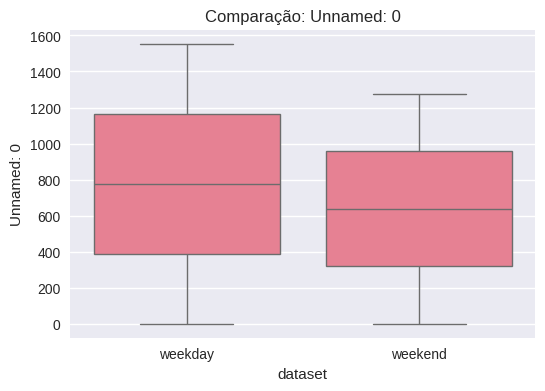

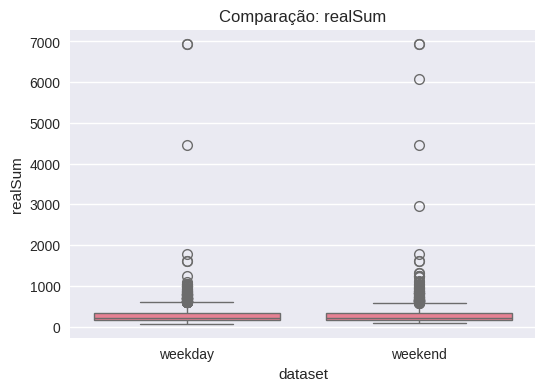

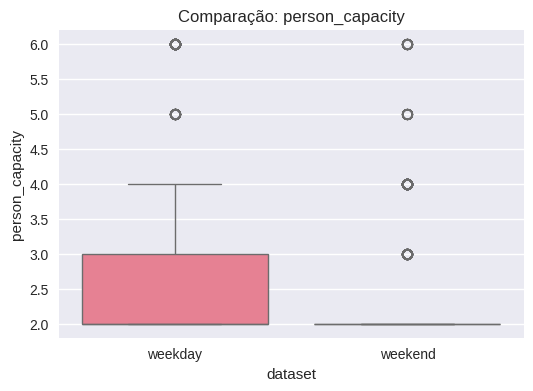

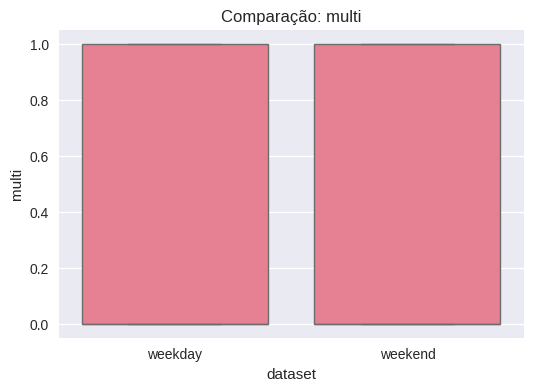

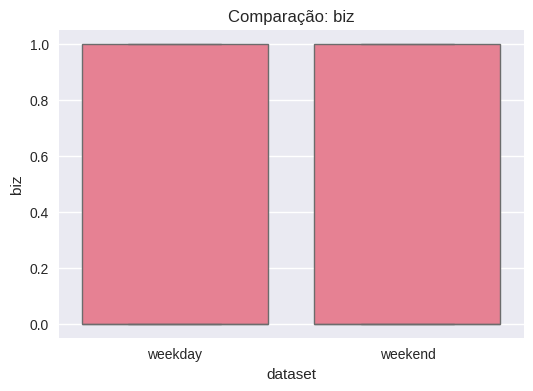

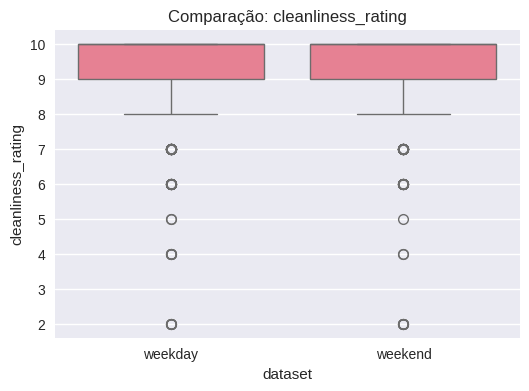

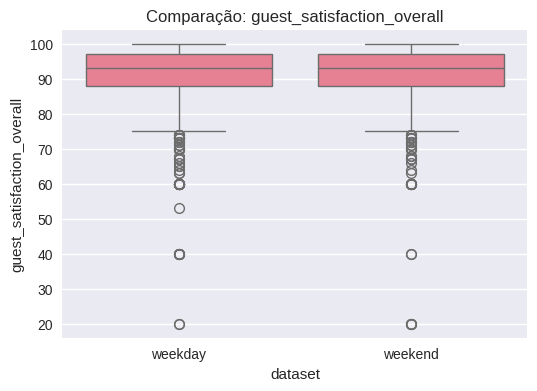

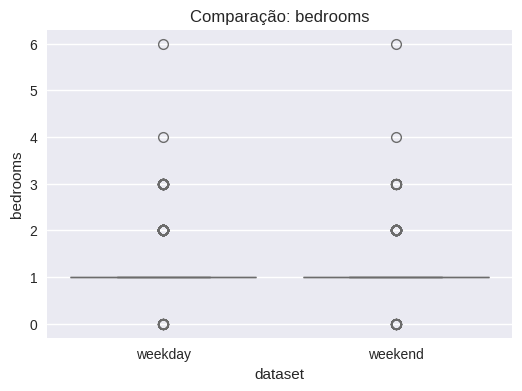

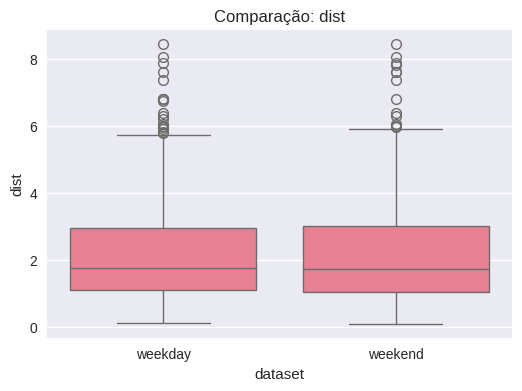

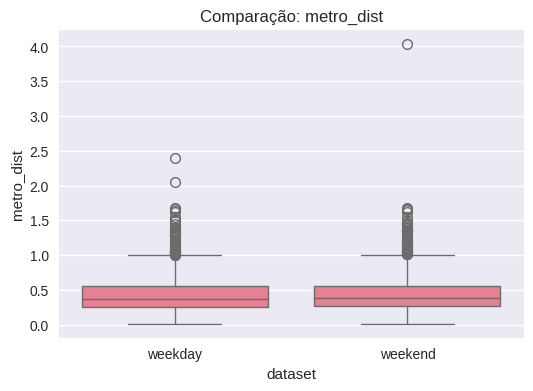

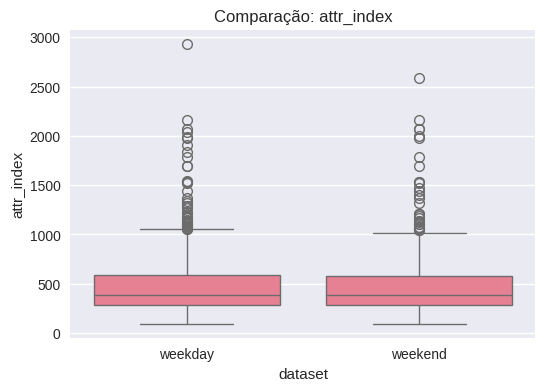

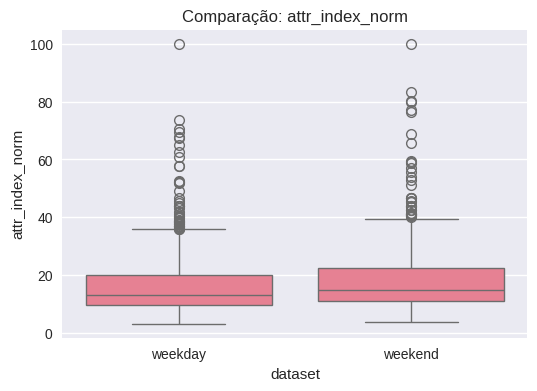

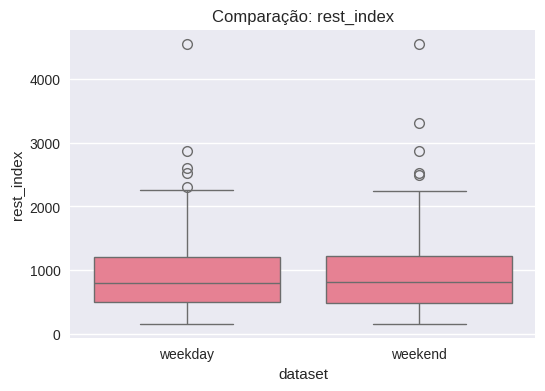

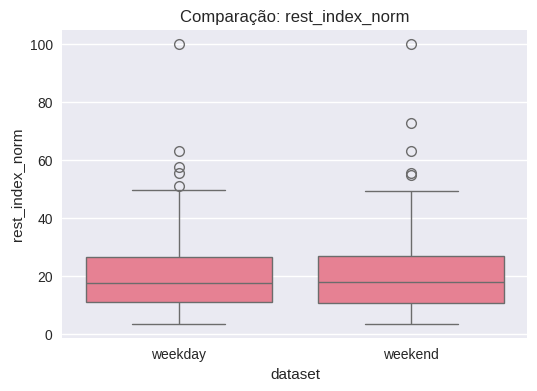

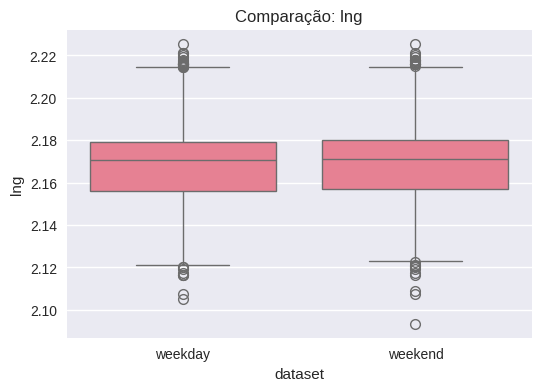

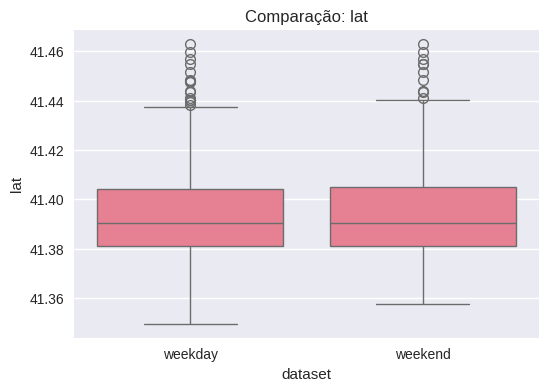

In [50]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_all, x="dataset", y=col)
    plt.title(f"Comparação: {col}")
    plt.show()


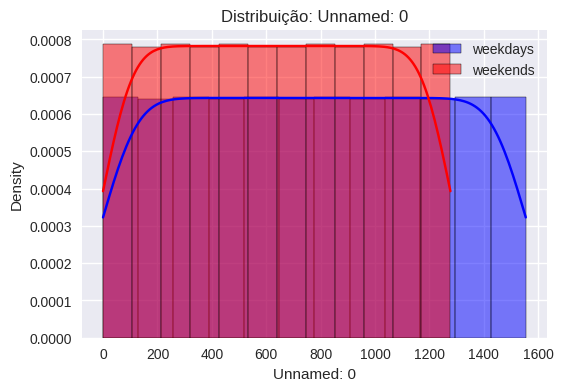

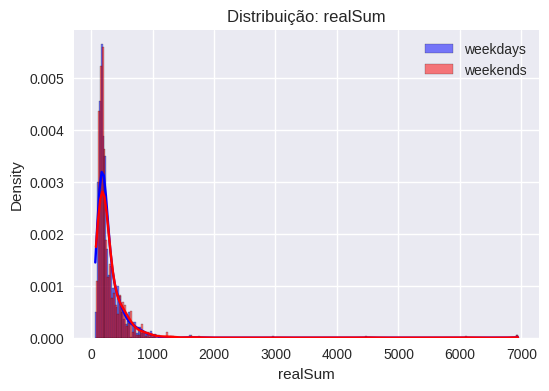

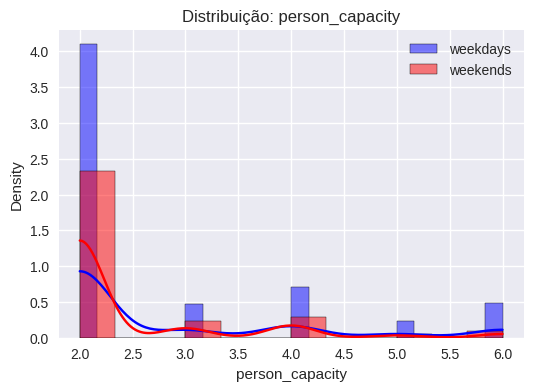

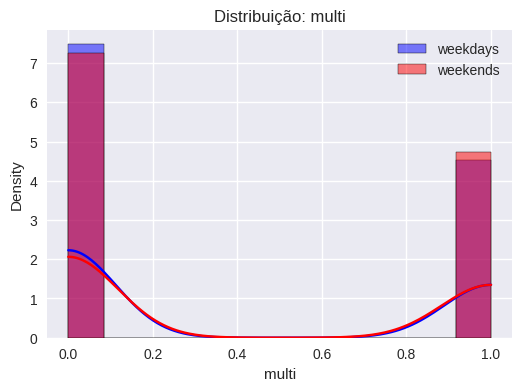

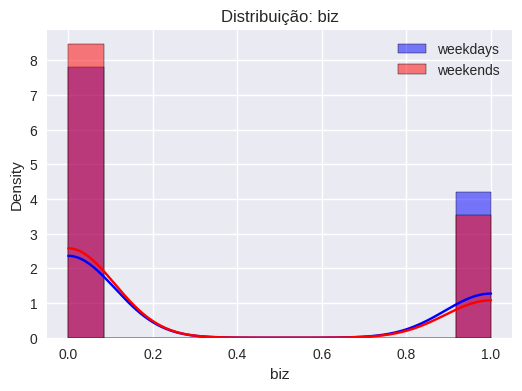

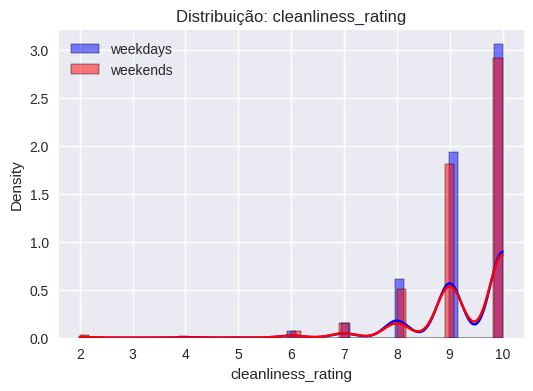

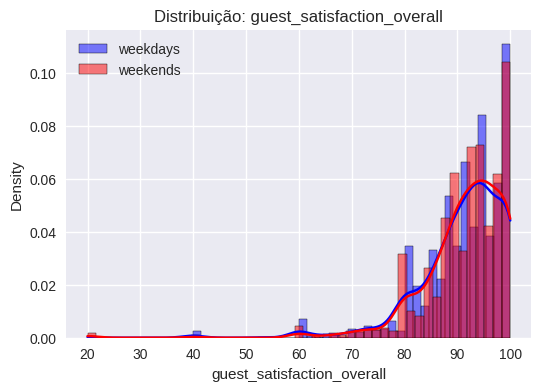

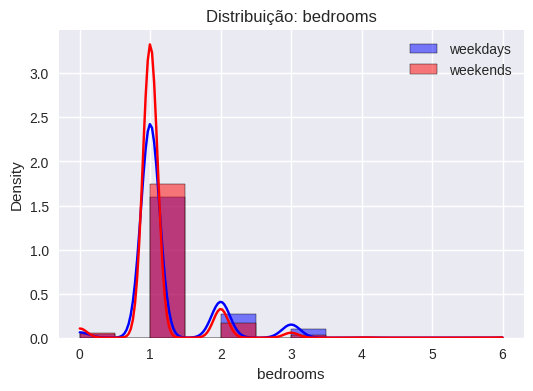

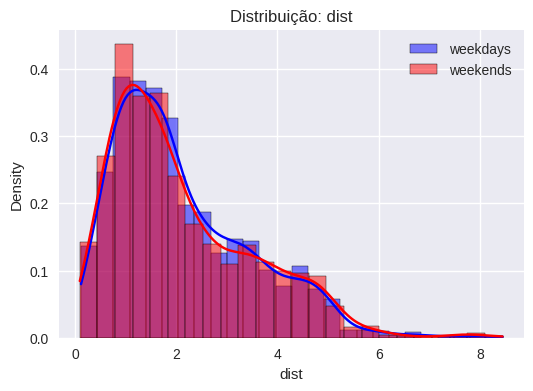

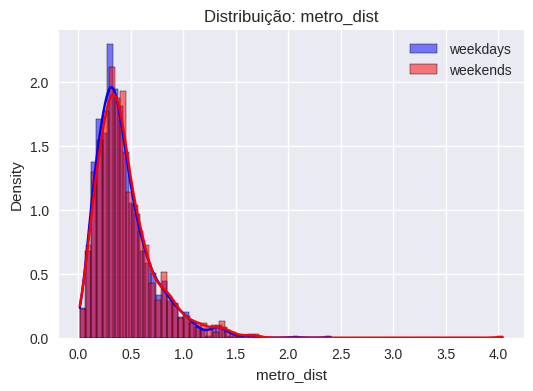

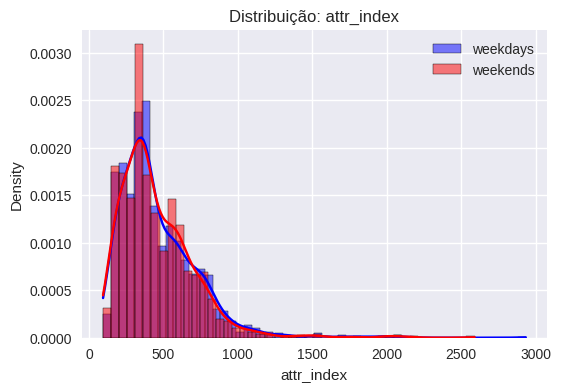

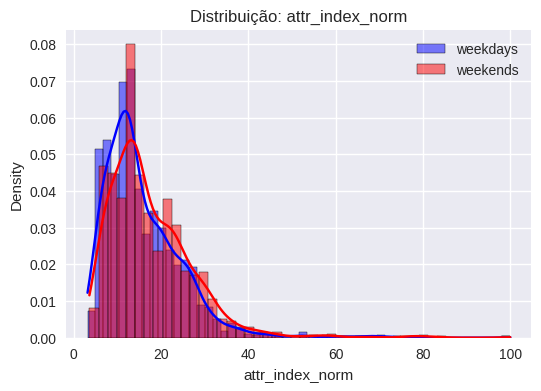

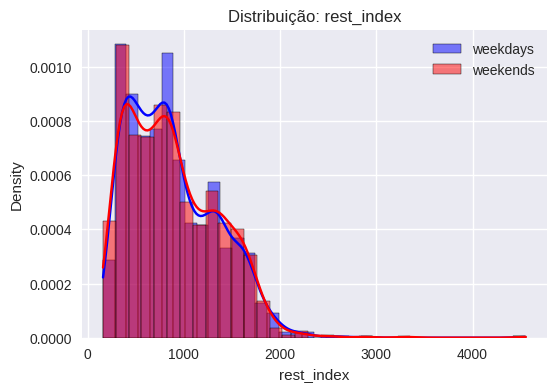

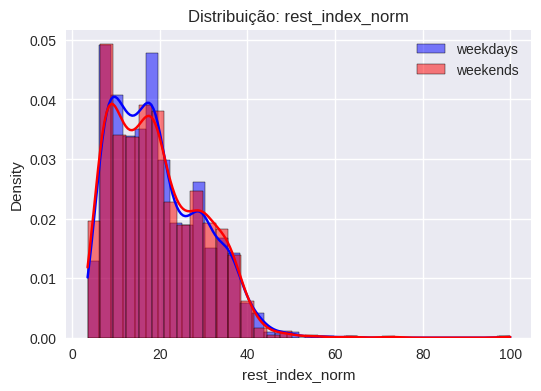

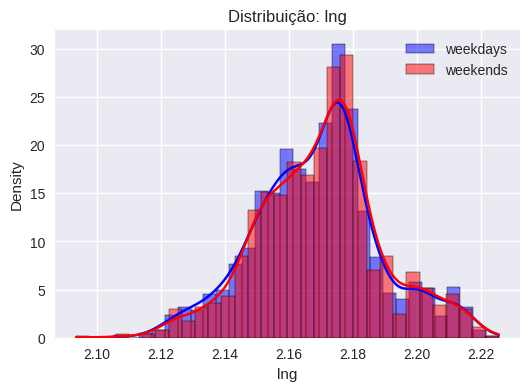

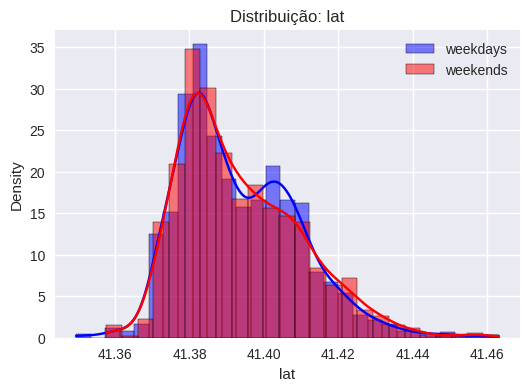

In [51]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_weekdays[col], kde=True, color="blue", label="weekdays", stat="density")
    sns.histplot(df_weekends[col], kde=True, color="red", label="weekends", stat="density")
    plt.legend()
    plt.title(f"Distribuição: {col}")
    plt.show()


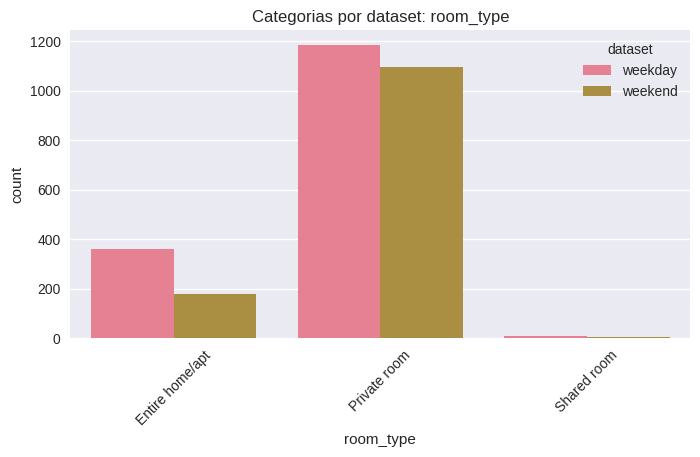

In [52]:
categorical_cols = df_all.select_dtypes(include=["object"]).columns
categorical_cols = [c for c in categorical_cols if c != "dataset"]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df_all, x=col, hue="dataset")
    plt.xticks(rotation=45)
    plt.title(f"Categorias por dataset: {col}")
    plt.show()


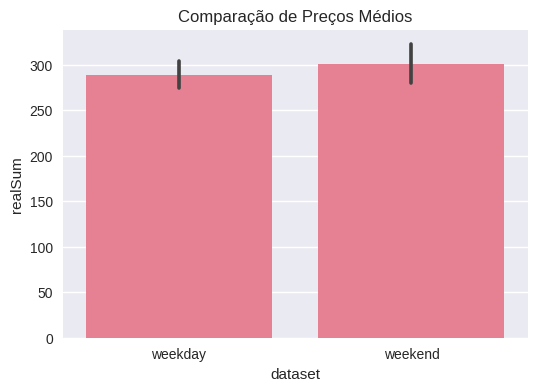

In [53]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=df_all,
    x="dataset",
    y="realSum"
)
plt.title("Comparação de Preços Médios")
plt.show()


Avaliação RealSum

In [54]:
# ============================
# 1. Estatísticas Descritivas
# ============================
num_vars = ['realSum','person_capacity','cleanliness_rating',
            'guest_satisfaction_overall','bedrooms',
            'dist','metro_dist','attr_index','attr_index_norm',
            'rest_index','rest_index_norm','lng','lat']

cat_vars = ['room_type','room_shared','room_private','host_is_superhost','multi','biz']

print("\n=== Estatísticas — realSum ===")
display(df_all.groupby("dataset")["realSum"].describe())


=== Estatísticas — realSum ===


,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
weekday,1555.0,288.391667,321.180435,69.588289,161.984779,208.532129,335.373659,6943.700980
weekend,1278.0,300.277940,393.207126,80.992390,159.657412,204.691973,327.169688,6942.770033


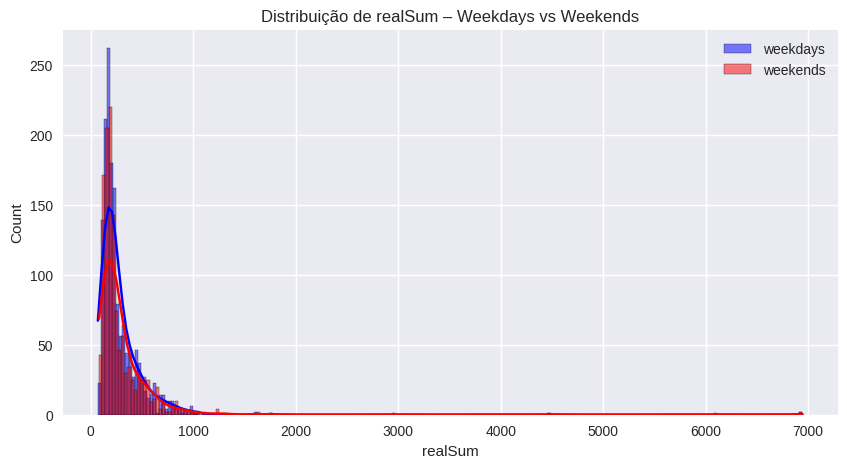

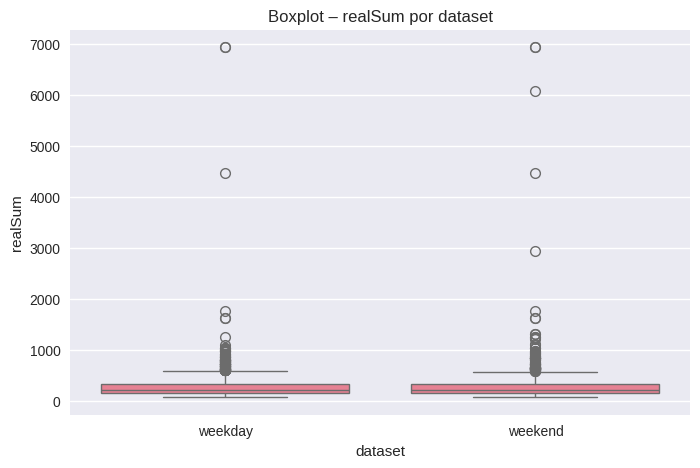

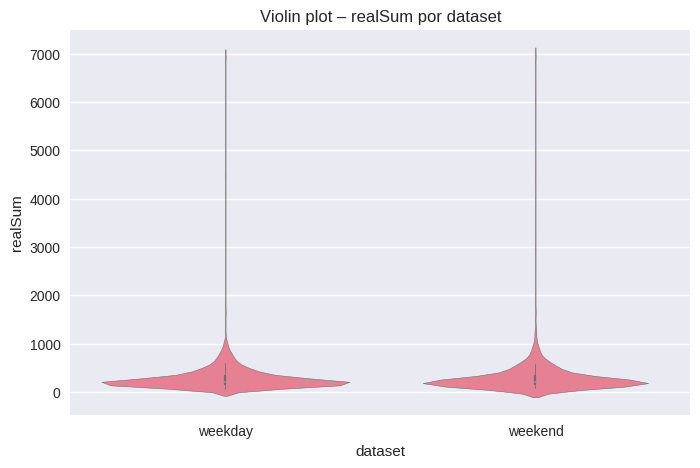

In [55]:
# ============================
# 2. Comparação de Distribuições
# ============================

plt.figure(figsize=(10,5))
sns.histplot(df_weekdays["realSum"], kde=True, color="blue", alpha=0.5, label="weekdays")
sns.histplot(df_weekends["realSum"], kde=True, color="red", alpha=0.5, label="weekends")
plt.title("Distribuição de realSum – Weekdays vs Weekends")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_all, x="dataset", y="realSum")
plt.title("Boxplot – realSum por dataset")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(data=df_all, x="dataset", y="realSum")
plt.title("Violin plot – realSum por dataset")
plt.show()


In [56]:
# ============================
# 3. Testes Estatísticos
# ============================
w1 = df_weekdays["realSum"]
w2 = df_weekends["realSum"]

print("\n=== Testes Estatísticos de realSum ===")
print("T-test p-value:", ttest_ind(w1, w2, equal_var=False).pvalue)
print("Mann-Whitney p-value:", mannwhitneyu(w1, w2).pvalue)
print("KS test p-value:", ks_2samp(w1, w2).pvalue)


=== Testes Estatísticos de realSum ===
T-test p-value: 0.38522120365284696
Mann-Whitney p-value: 0.7020701500680315
KS test p-value: 0.26709091405016355


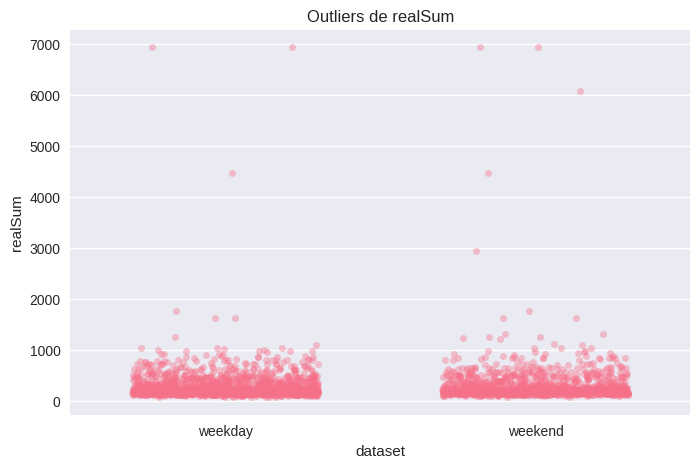

In [57]:
# ============================
# 4. Outliers
# ============================

plt.figure(figsize=(8,5))
sns.stripplot(data=df_all, x="dataset", y="realSum", alpha=0.4, jitter=0.3)
plt.title("Outliers de realSum")
plt.show()

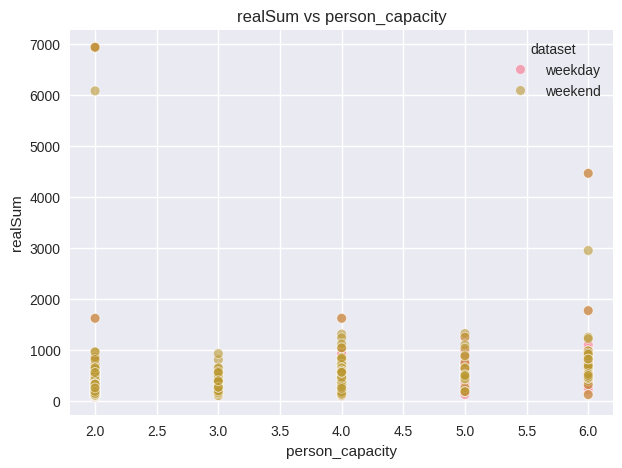

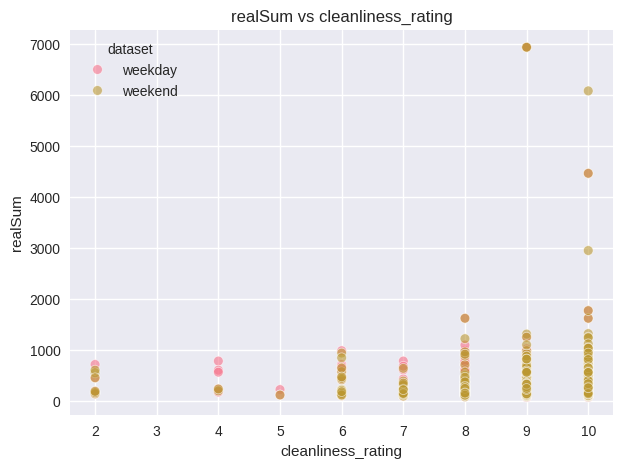

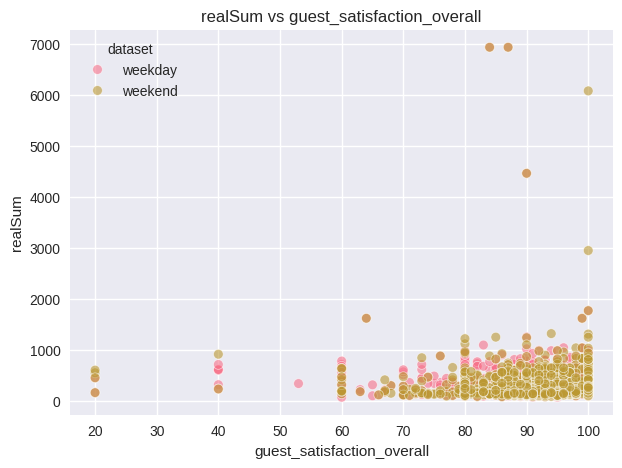

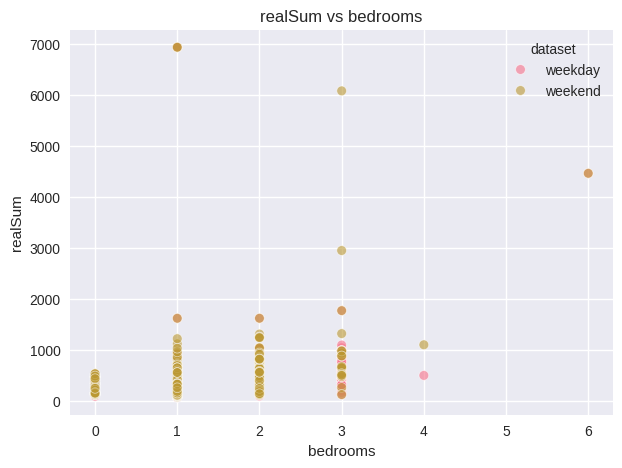

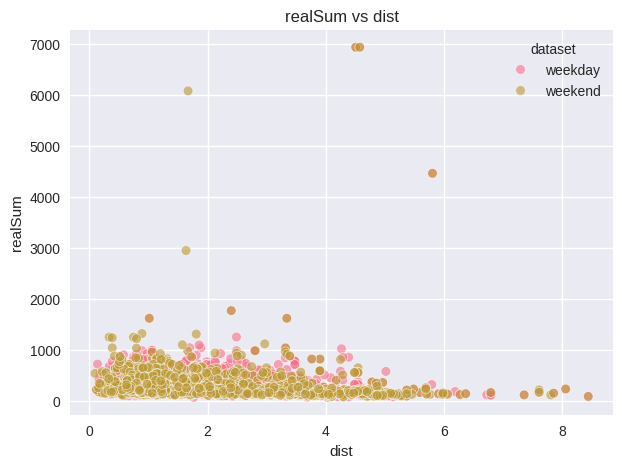

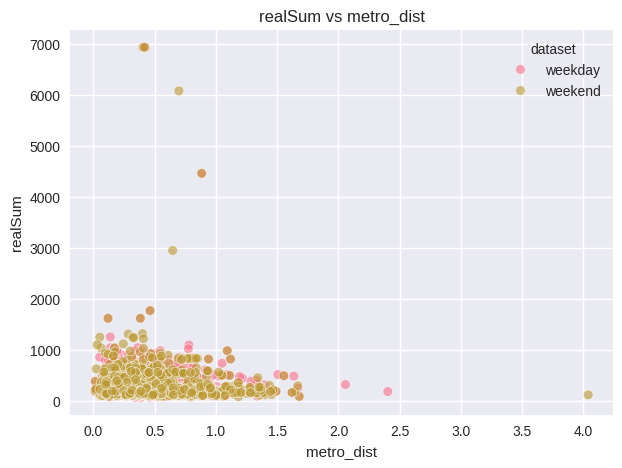

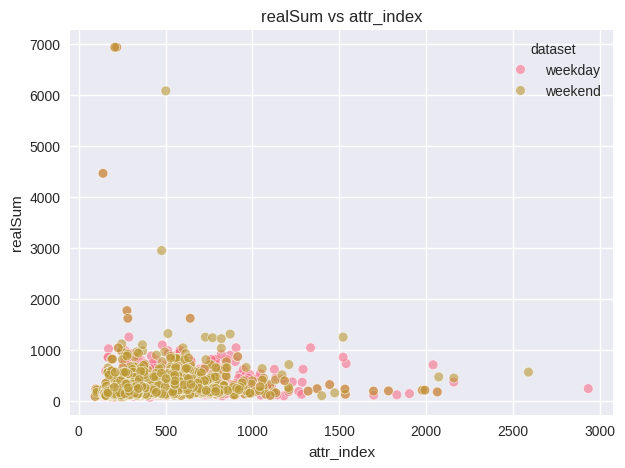

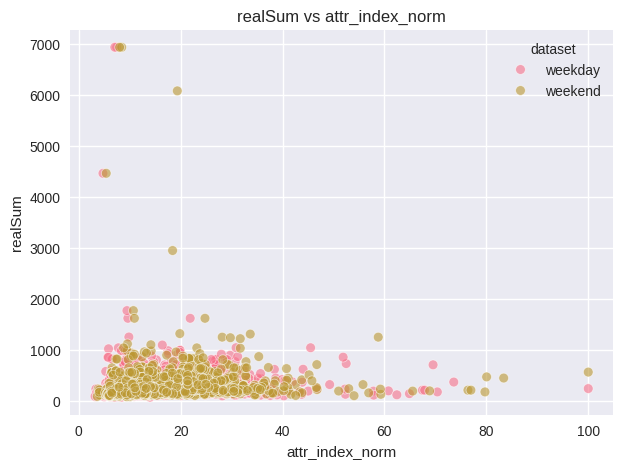

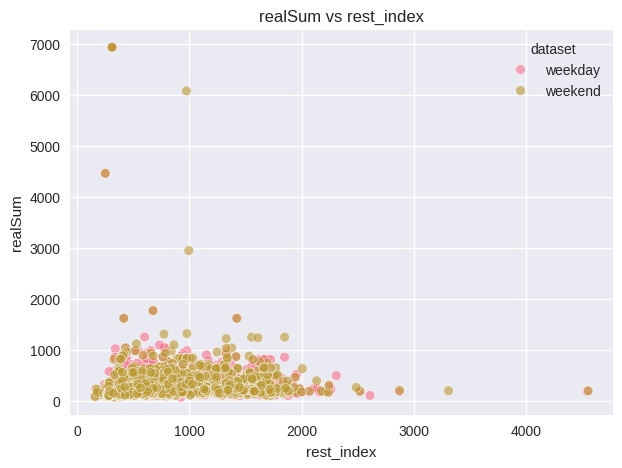

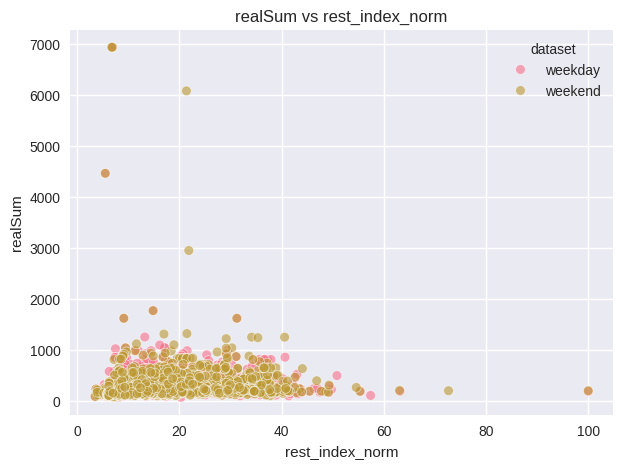

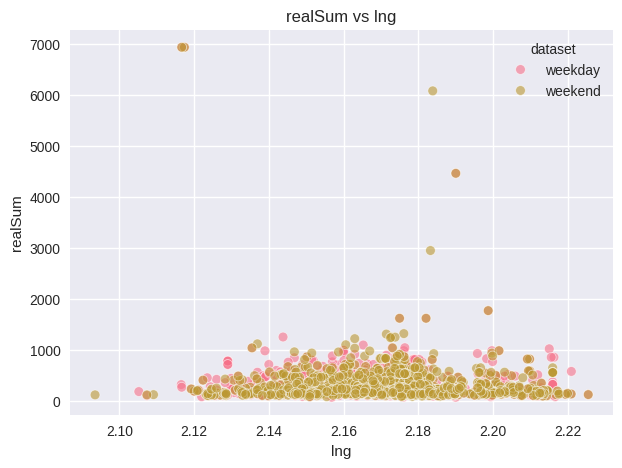

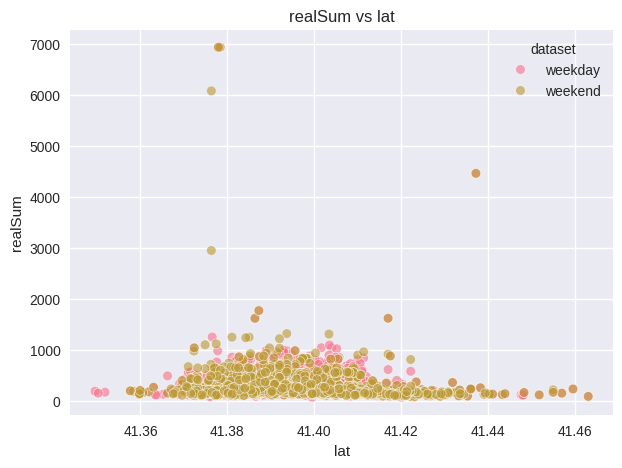

In [58]:
# ============================
# 5. Relação com Numéricas
# ============================

for col in num_vars:
    if col == "realSum":
        continue
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_all, x=col, y="realSum", hue="dataset", alpha=0.6)
    plt.title(f"realSum vs {col}")
    plt.show()


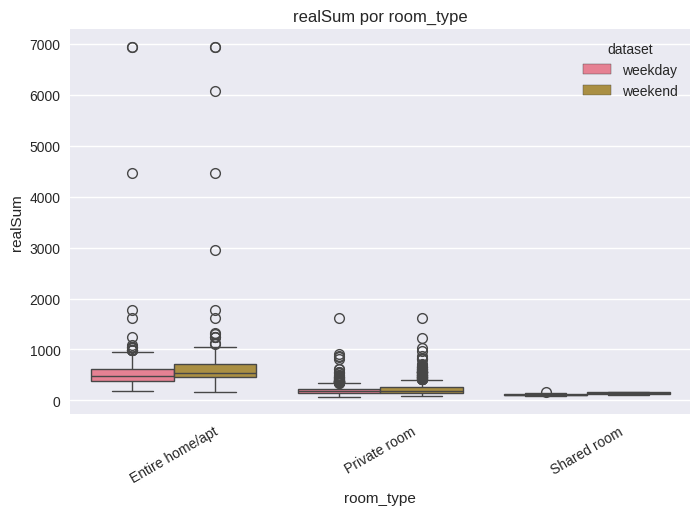

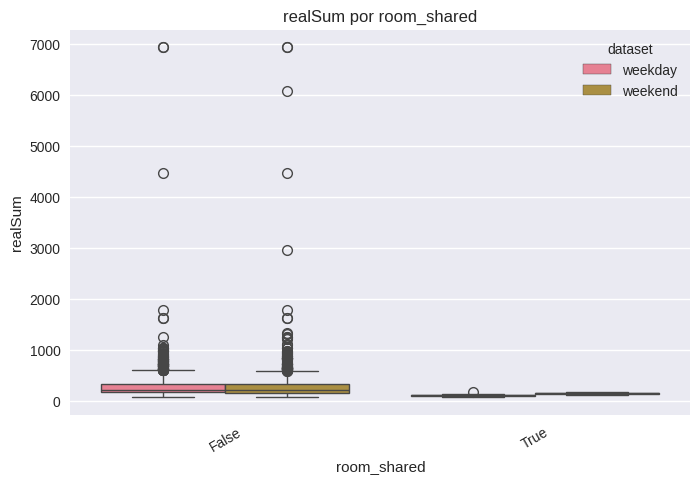

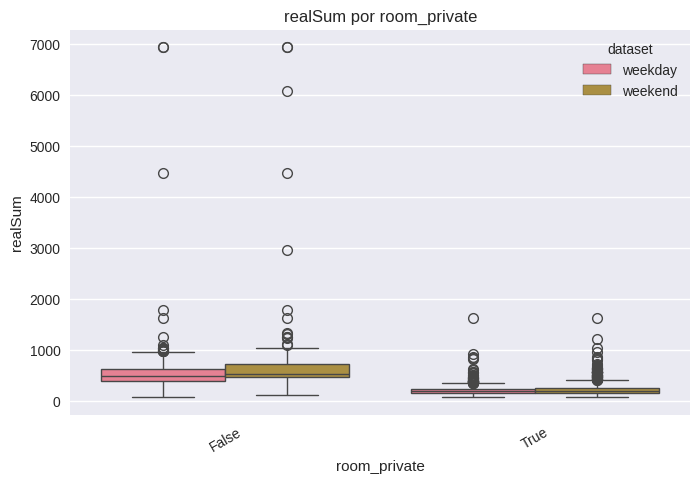

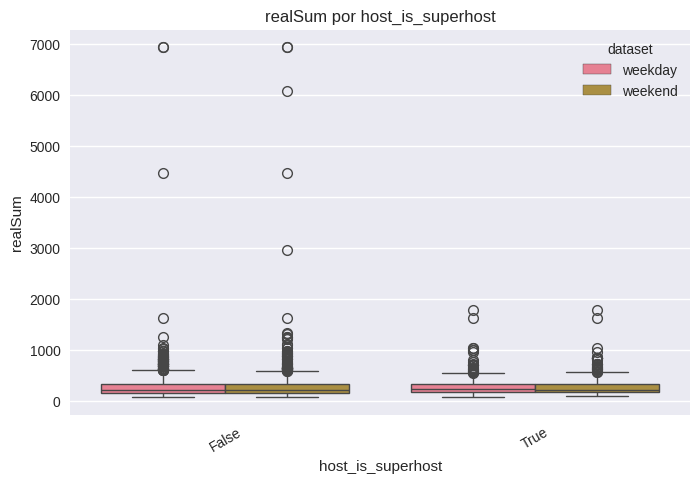

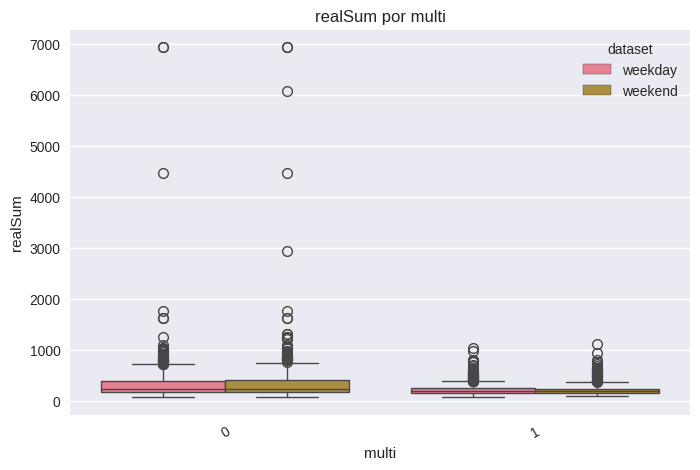

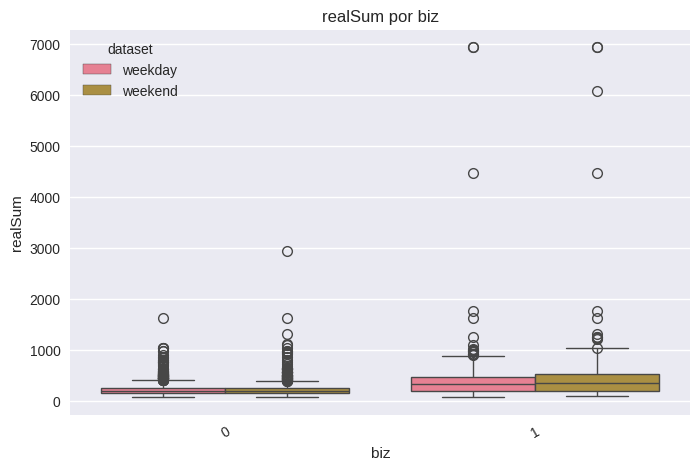

In [59]:

# ============================
# 6. Relação com Categóricas
# ============================

for col in cat_vars:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df_all, x=col, y="realSum", hue="dataset")
    plt.title(f"realSum por {col}")
    plt.xticks(rotation=30)
    plt.show()

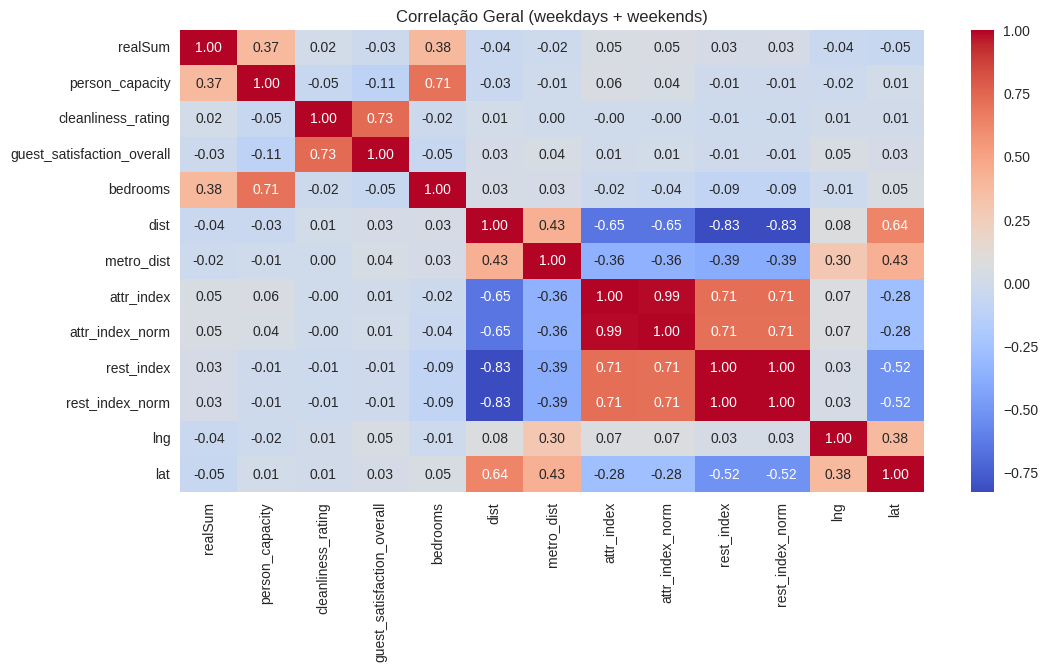

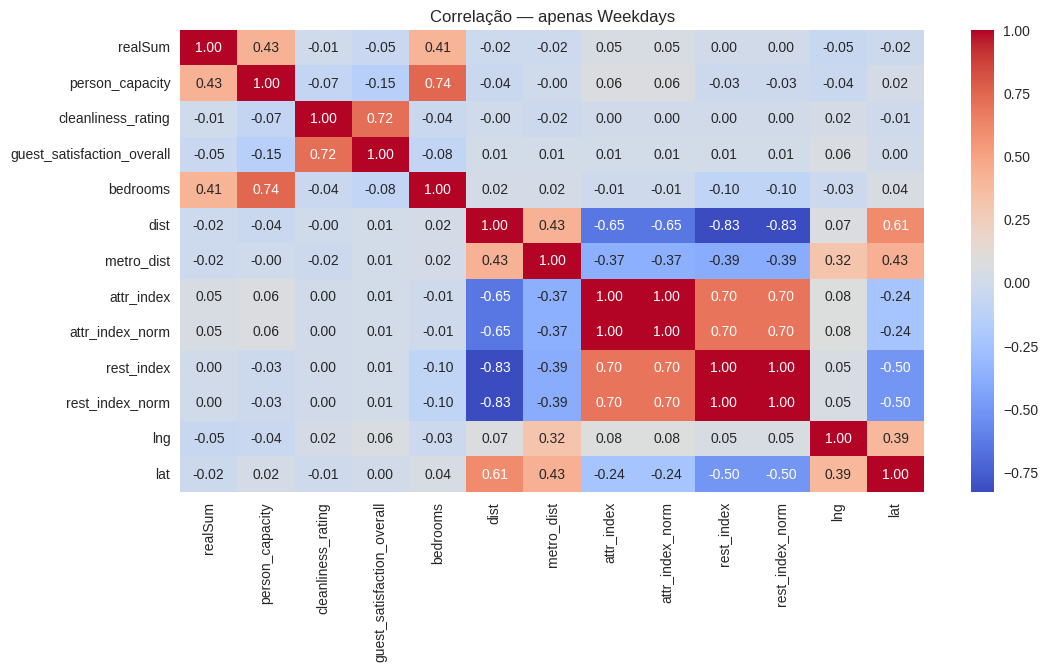

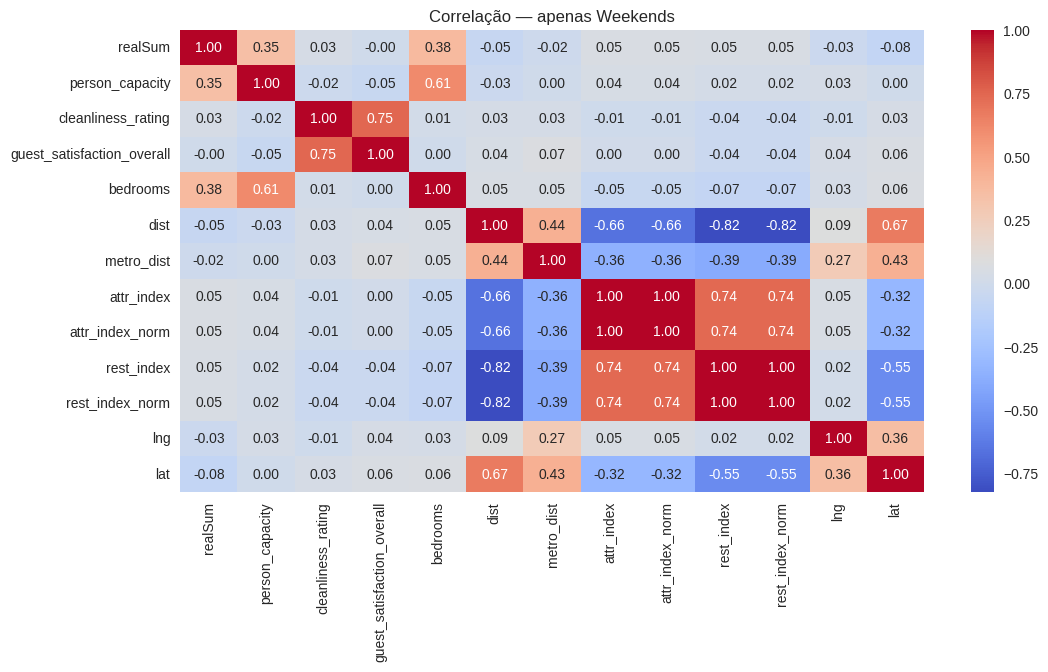

In [60]:
# ============================
# 7. Correlações Numéricas
# ============================

plt.figure(figsize=(12,6))
sns.heatmap(df_all[num_vars].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação Geral (weekdays + weekends)")
plt.show()

# Correlações separadas
plt.figure(figsize=(12,6))
sns.heatmap(df_weekdays[num_vars].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação — apenas Weekdays")
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df_weekends[num_vars].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlação — apenas Weekends")
plt.show()

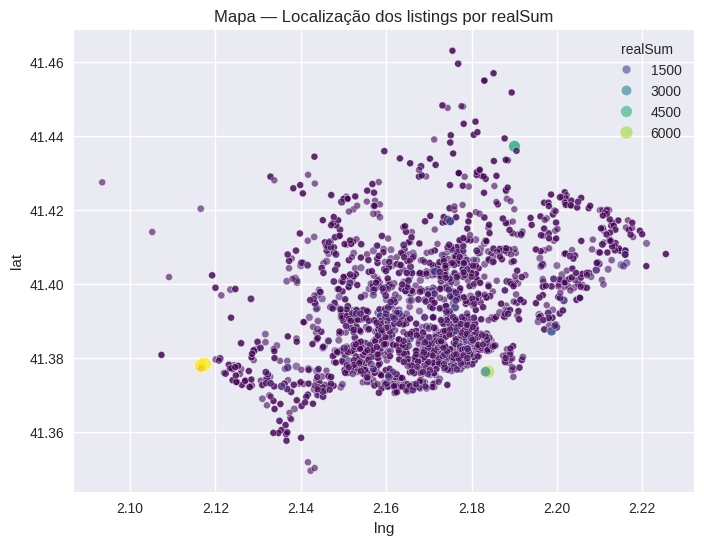

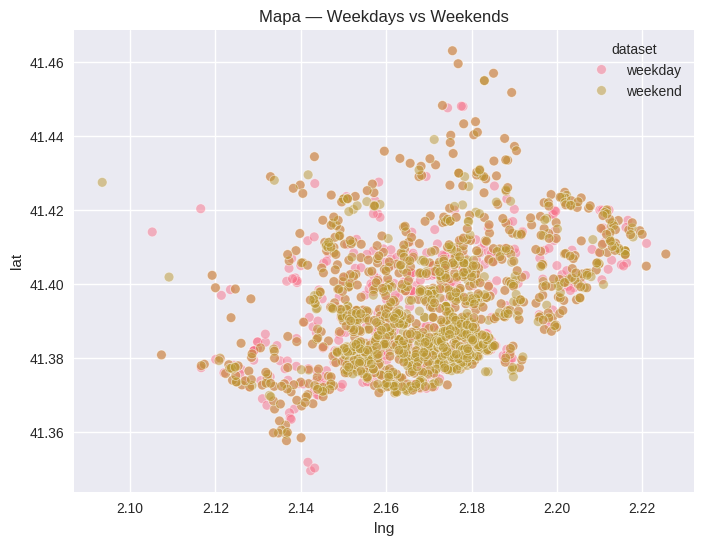

In [61]:
# ============================
# 8. Análise Espacial
# ============================

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="lng", y="lat", hue="realSum", size="realSum",
                alpha=0.6, palette="viridis")
plt.title("Mapa — Localização dos listings por realSum")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="lng", y="lat", hue="dataset", alpha=0.5)
plt.title("Mapa — Weekdays vs Weekends")
plt.show()